h = 0.10 | Total accumulated error = 4.151241


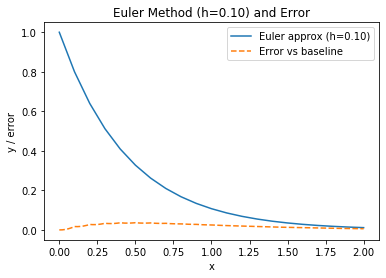

h = 0.15 | Total accumulated error = 5.466933


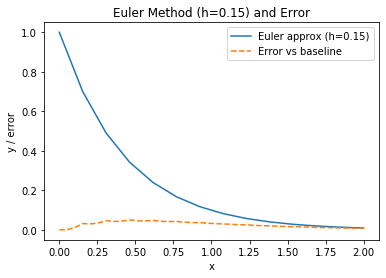

h = 0.20 | Total accumulated error = 4.730590


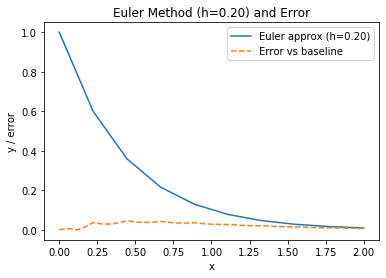

h = 0.25 | Total accumulated error = 6.292132


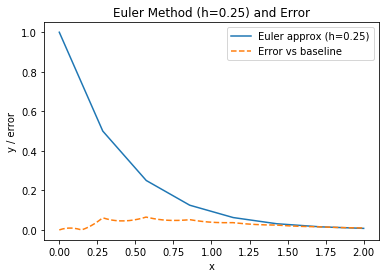

h = 0.30 | Total accumulated error = 10.000427


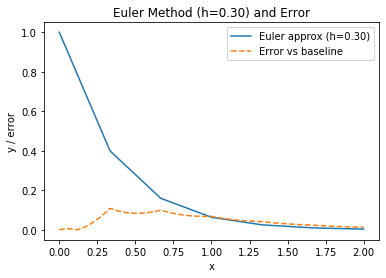

h = 0.35 | Total accumulated error = 11.766286


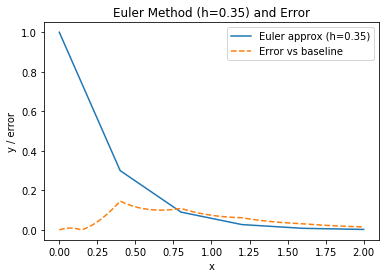

h = 0.40 | Total accumulated error = 11.943864


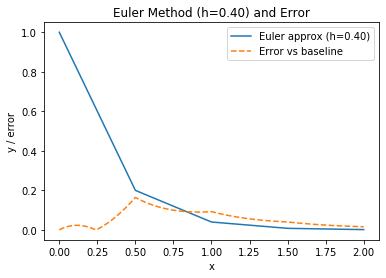

h = 0.45 | Total accumulated error = 18.181313


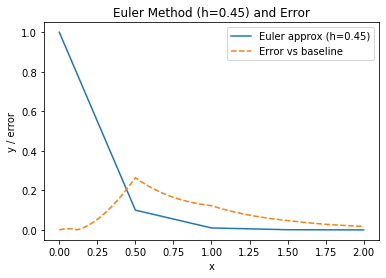

h = 0.50 | Total accumulated error = 16.811505


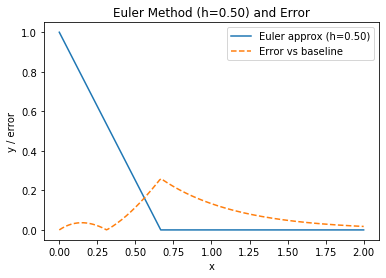

h = 0.55 | Total accumulated error = 21.832457


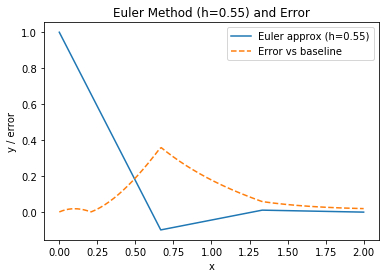

h = 0.60 | Total accumulated error = 26.335943


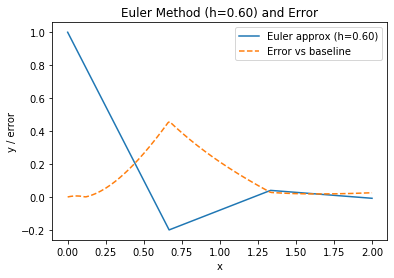

h = 0.65 | Total accumulated error = 31.065637


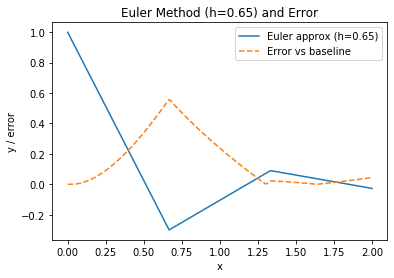

h = 0.70 | Total accumulated error = 36.803162


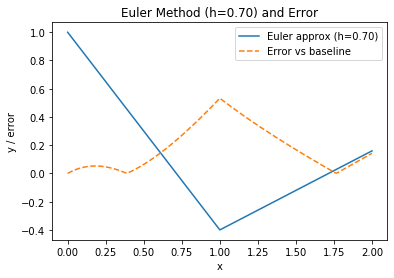

h = 0.75 | Total accumulated error = 44.560328


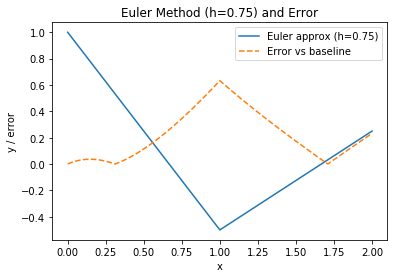

h = 0.80 | Total accumulated error = 53.211340


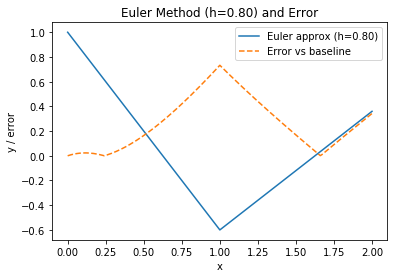

h = 0.85 | Total accumulated error = 62.722870


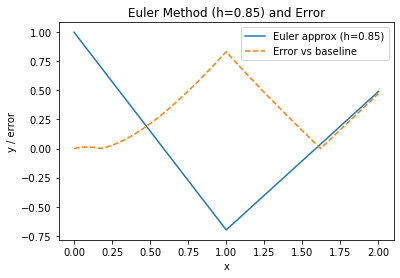

h = 0.90 | Total accumulated error = 73.074012


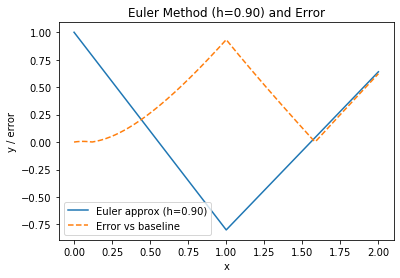

h = 0.95 | Total accumulated error = 84.235096


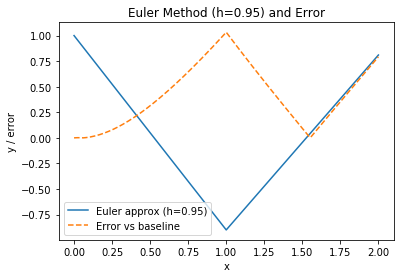

In [46]:
import numpy as np
import matplotlib.pyplot as plt

#function
def f(x, y):
    return -2 * y

x_start, x_end = 0, 2

#creating a fine grid
h_base = 0.01
num_steps_base = int((x_end - x_start) / h_base)

x_base = np.linspace(x_start, x_end, num_steps_base + 1)
y_base = np.zeros(num_steps_base + 1)
y_base[0] = 1

#creating the reference for error 
for i in range(num_steps_base):
    y_base[i + 1] = y_base[i] + h_base * f(x_base[i], y_base[i])

#interating for all other step sizes
for h in np.arange(0.1, 1, 0.05):

    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    y_values[0] = 1

    # Euler method
    for j in range(num_steps):
        y_values[j + 1] = y_values[j] + h * f(x_values[j], y_values[j])
    
    #finding out what the horrible step size would have been at a finer number (fine grid)
    y_interp = np.interp(x_base, x_values, y_values)

    #error on fine grid
    error = np.abs(y_interp - y_base)

    total_error = np.sum(error)

    print(f"h = {h:.2f} | Total accumulated error = {total_error:.6f}")

    plt.figure()
    plt.plot(x_values, y_values, label=f"Euler approx (h={h:.2f})")
    plt.plot(x_base, error, label="Error vs baseline", linestyle='--')
    plt.xlabel('x')
    plt.ylabel('y / error')
    plt.title(f"Euler Method (h={h:.2f}) and Error")
    plt.legend()
    plt.show()